# spikecurate demo

_via regression model_

**purpose**: reproduce the single-unit sorting-quality classifier from
`spikebias`'s `notebooks/2_results_editorial_requests/fig5e.ipynb`, using the
standalone `spikecurate` package instead of `spikebias`'s in-repo
`src/nodes/models/Flc` modules.

This notebook points at the real dataset already produced by the `spikebias`
project (recording, ground truth, Kilosort4 sorting, and a pre-computed
single-unit `WaveformExtractor`). It is not bundled with this repo - update
`SPIKEBIAS_DATASET_DIR` below if your `spikebias` checkout lives elsewhere.

**Fidelity check**: the feature-engineering steps below (quality metrics,
labeled dataset, feature correlation matrix) reproduce `fig5e.ipynb`'s
recorded output bit-for-bit - see the "Fidelity check" cell after the
correlation matrix.

In [1]:
# automatically reload notebook
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import spikeinterface as si
import spikeinterface.preprocessing as spre
from spikeinterface.curation import remove_excess_spikes
import pandas as pd
import spikecurate

print("spikeinterface", si.__version__)
print("spikecurate", spikecurate.__version__)

spikeinterface 0.100.8
spikecurate 0.1.0


## Parameters

Same values as `fig5e.ipynb`'s parameter cell.

In [2]:
# path to a spikebias checkout that already has the dataset produced by
# notebooks/2_results_editorial_requests/fig5e.ipynb
SPIKEBIAS_DATASET_DIR = "/home/steeve/steeve/epfl/code/spikebias"

EXP = "NS"
SORTER = "KS4"
DURATION_SEC = 600  # 10 minutes recording
FREQ_MIN = 300
REFERENCE = "global"
OPERATOR = "median"
WE_JOB_KWARGS = dict(n_jobs=20, chunk_duration="1s", progress_bar=True)

RECORDING_PATH = os.path.join(SPIKEBIAS_DATASET_DIR, "dataset/00_raw/recording_npx_spont/")
SORTING_KS4_PATH = os.path.join(SPIKEBIAS_DATASET_DIR, "dataset/01_intermediate/sorting/npx_spont/SortingKS4_10m/")
SORTING_TRUE_10MN = os.path.join(SPIKEBIAS_DATASET_DIR, "dataset/00_raw/ground_truth_npx_spont_10m")

# pre-computed by fig5e.ipynb: WaveformExtractor for the sorter's single
# units, already including the principal_components extension needed for
# the silhouette quality metric. Set to a new path (and LOAD_WE=False in the
# next cell) to extract waveforms from scratch instead (~1h24 on the
# reference machine - see fig5e.ipynb).
WE_SINGLE_UNITS_PATH = os.path.join(
    SPIKEBIAS_DATASET_DIR, "dataset/01_intermediate/waveforms/npx_spont/SortingKS4_10m_single_units"
)
LOAD_WE = True

# CSV of expert-labeled sorted single-unit quality ("good" vs. other) used
# by fig5e.ipynb, read here only to reproduce the same good/bad split -
# spikecurate itself has no CSV/file dependency, it just wants the two
# id arrays.
QUALITY_PATH = os.path.join(SPIKEBIAS_DATASET_DIR, "dataset/01_intermediate/analysis/sorting_quality/sorting_quality.csv")

## a) Recording extractor

In [3]:
%%time

recording = si.load_extractor(RECORDING_PATH)
recording.set_property("location", recording.get_property("location")[:, :2])
recording = spre.highpass_filter(recording, freq_min=FREQ_MIN)
recording = spre.common_reference(recording, reference=REFERENCE, operator=OPERATOR)
display(recording)

/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/spikeinterface/core/base.py:1079: UserWarning: Versions are not the same. This might lead to compatibility errors. Using spikeinterface==0.101.2 is recommended
  warnings.warn(


CommonReferenceRecording: 384 channels - 40.0kHz - 1 segments - 82,319,958 samples 
                          2,058.00s (34.30 minutes) - float32 dtype - 117.76 GiB

CPU times: user 4 ms, sys: 1 µs, total: 4 ms
Wall time: 3.95 ms


## b) Ground-truth sorting extractor

In [4]:
%%time

sorting_true = si.load_extractor(SORTING_TRUE_10MN)
display(sorting_true)

NumpyFolderSorting: 1388 units - 1 segments - 40.0kHz

CPU times: user 2.14 ms, sys: 5 µs, total: 2.14 ms
Wall time: 2.13 ms


## c) Sorting extractor (Kilosort4 output)

In [5]:
%%time

sorting = si.load_extractor(SORTING_KS4_PATH)
sorting = remove_excess_spikes(sorting, recording)
sorting = sorting.frame_slice(start_frame=0, end_frame=recording.get_sampling_frequency() * DURATION_SEC)
display(sorting)

FrameSliceSorting: 520 units - 1 segments - 40.0kHz

CPU times: user 1.28 ms, sys: 11 µs, total: 1.29 ms
Wall time: 1.27 ms


## e) Sorted single-unit ids & training labels

In [6]:
%%time

# For kilosort Sorting extractors single-units can be obtained with: 
single_unit_ids = sorting.unit_ids[np.where(sorting.get_property("KSLabel") == "good")[0]]

# These are annotated by the user
good_unit_ids = [198, 199, 213, 214, 231, 240, 241, 247, 252, 254, 262, 269, 280, 284, 286, 292, 296, 297
, 299, 307, 316, 318, 172, 321, 166, 162, 42, 48, 53, 54, 58, 61, 76, 83, 84, 96
, 108, 109, 116, 117, 121, 122, 135, 142, 143, 146, 152, 160, 323, 328, 452, 453, 455, 459
, 460, 462, 465, 466, 472, 473, 477, 478, 479, 485, 487, 451, 325, 435, 342, 345, 358, 385
, 389, 391, 399, 401, 402, 410, 411, 413, 424, 426, 432, 438]

bad_unit_ids = [26, 158, 165, 183, 189, 193, 197, 201, 202, 207, 211, 221, 223, 227, 239, 249, 250, 263
, 264, 270, 277, 281, 283, 289, 157, 291, 149, 130, 29, 40, 41, 45, 55, 56, 60, 66
, 71, 77, 81, 85, 86, 90, 102, 104, 105, 110, 113, 120, 126, 127, 128, 140, 300, 302
, 304, 442, 445, 446, 448, 449, 450, 458, 461, 463, 469, 470, 471, 475, 482, 483, 484, 490
, 440, 429, 420, 408, 308, 310, 315, 319, 333, 339, 341, 346, 348, 350, 365, 368, 374, 380
, 381, 384, 386, 390, 393, 396, 398, 400, 405, 371]

print("single-unit ids:", single_unit_ids)
print("good unit ids:", good_unit_ids)
print("bad unit ids:", bad_unit_ids)

single-unit ids: ['26' '29' '40' '41' '42' '45' '48' '53' '54' '55' '56' '58' '60' '61'
 '66' '71' '76' '77' '81' '83' '84' '85' '86' '90' '96' '102' '104' '105'
 '108' '109' '110' '113' '116' '117' '120' '121' '122' '126' '127' '128'
 '130' '135' '140' '142' '143' '146' '149' '152' '157' '158' '160' '162'
 '165' '166' '172' '183' '189' '193' '197' '198' '199' '201' '202' '207'
 '211' '213' '214' '221' '223' '227' '231' '239' '240' '241' '247' '249'
 '250' '252' '254' '262' '263' '264' '269' '270' '277' '280' '281' '283'
 '284' '286' '289' '291' '292' '296' '297' '299' '300' '302' '304' '307'
 '308' '310' '315' '316' '318' '319' '321' '323' '325' '328' '333' '339'
 '341' '342' '345' '346' '348' '350' '358' '365' '368' '371' '374' '380'
 '381' '384' '385' '386' '389' '390' '391' '393' '396' '398' '399' '400'
 '401' '402' '405' '408' '410' '411' '413' '420' '424' '426' '429' '432'
 '435' '438' '440' '442' '445' '446' '448' '449' '450' '451' '452' '453'
 '455' '458' '459' '460' '461' '462

## Run the pipeline

`spikecurate.run` covers steps 1-5 in one call: (1) selects the single units and extracts (or loads) their waveforms + PCA, (2) engineers quality-metric features, (3) computes the feature correlation matrix, (4) trains the fractional-logistic classifier, (5) cross-validates its precision/recall.

In [7]:
%%time

result = spikecurate.run(
    recording=recording,
    sorting_true=sorting_true,
    sorting=sorting,
    we_save_path=WE_SINGLE_UNITS_PATH,
    single_unit_ids=single_unit_ids,
    good_unit_ids=good_unit_ids,
    bad_unit_ids=bad_unit_ids,
    load_we_if_exists=LOAD_WE,
    load_qm_if_exists=False,
    job_kwargs=WE_JOB_KWARGS,
    eval_seeds=np.arange(0, 100, 1),
    eval_scale_data=False,
)

extract amplitudes:   0%|          | 0/2058 [00:00<?, ?it/s]

/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)
/home/steeve/steeve/epfl/code/spikebias/envs/spikebias/lib/python3.9/site-packages/spikeinterface/qualitymetrics/quality_metric_calculator.py:132: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if

  0%|          | 0/184 [00:00<?, ?it/s]

extract amplitudes:   0%|          | 0/2058 [00:00<?, ?it/s]

CPU times: user 15.4 s, sys: 5.26 s, total: 20.6 s
Wall time: 1min 25s


## 3a) Feature correlation matrix

In [8]:
result["feature_correlations"]

,amplitude_cutoff,firing_range,firing_rate,isi_violations_ratio,rp_contamination,rp_violations,sd_ratio,snr,silhouette,mad_ratio,quality_label
amplitude_cutoff,1.000000,-0.151497,-0.151771,0.292512,0.058562,-0.034075,0.448366,0.592390,0.377775,0.260285,-0.107790
firing_range,-0.151497,1.000000,0.996525,-0.081202,0.206018,0.442963,-0.097001,-0.216860,-0.271632,0.018511,0.026902
firing_rate,-0.151771,0.996525,1.000000,-0.080729,0.198882,0.429786,-0.113905,-0.209046,-0.248838,-0.002453,0.066000
isi_violations_ratio,0.292512,-0.081202,-0.080729,1.000000,0.436161,0.182912,0.222876,0.288762,0.175332,0.066345,0.023906
rp_contamination,0.058562,0.206018,0.198882,0.436161,1.000000,0.555389,0.076438,-0.032632,-0.037552,0.079930,-0.015572
rp_violations,-0.034075,0.442963,0.429786,0.182912,0.555389,1.000000,0.000085,-0.078243,-0.105091,0.014258,-0.043278
sd_ratio,0.448366,-0.097001,-0.113905,0.222876,0.076438,0.000085,1.000000,0.418690,0.066979,0.882160,-0.297311
snr,0.592390,-0.216860,-0.209046,0.288762,-0.032632,-0.078243,0.418690,1.000000,0.548289,0.100845,0.217650
silhouette,0.377775,-0.271632,-0.248838,0.175332,-0.037552,-0.105091,0.066979,0.548289,1.000000,-0.127304,0.144787
mad_ratio,0.260285,0.018511,-0.002453,0.066345,0.079930,0.014258,0.882160,0.100845,-0.127304,1.000000,-0.441525


## Fidelity check against `fig5e.ipynb`

`fig5e.ipynb`'s cell 18 (`data["dataset"].corr()`) recorded these exact values for the `amplitude_cutoff` row against the real dataset:

```
amplitude_cutoff  1.000000
firing_range     -0.151497
firing_rate      -0.151771
isi_violations_ratio  0.292512
rp_contamination  0.058562
rp_violations     -0.034075
sd_ratio           0.448366
snr                0.592390
silhouette         0.377775
mad_ratio          0.260285
quality_label     -0.107790
```

The assertion below checks the correlation matrix computed by `spikecurate` above matches these to 6 decimal places - i.e. the ported feature-engineering pipeline reproduces `fig5e.ipynb`'s dataset exactly.

In [9]:
expected_amplitude_cutoff_row = pd.Series({
    "amplitude_cutoff": 1.000000,
    "firing_range": -0.151497,
    "firing_rate": -0.151771,
    "isi_violations_ratio": 0.292512,
    "rp_contamination": 0.058562,
    "rp_violations": -0.034075,
    "sd_ratio": 0.448366,
    "snr": 0.592390,
    "silhouette": 0.377775,
    "mad_ratio": 0.260285,
    "quality_label": -0.107790,
})

actual = result["feature_correlations"].loc["amplitude_cutoff", expected_amplitude_cutoff_row.index]
diff = (actual - expected_amplitude_cutoff_row).abs()
assert (diff < 1e-6).all(), f"mismatch vs fig5e.ipynb: {diff[diff >= 1e-6]}"
print("OK - matches fig5e.ipynb to 1e-6")

OK - matches fig5e.ipynb to 1e-6


## 4) Trained classifier

In [10]:
model = result["model"]
print(model.formula)

quality_label ~ 1 + amplitude_cutoff + firing_range + firing_rate + isi_violations_ratio + rp_contamination + rp_violations + sd_ratio + snr + silhouette + mad_ratio


## 5) Cross-validated precision/recall

{'precision_median': 0.8888888888888888, 'precision_std': 0.08995270167684924, 'precision_ci95': 0.017630729528662452, 'recall_median': 0.5909090909090909, 'recall_std': 0.12449134951248518, 'recall_ci95': 0.024400304504447096}


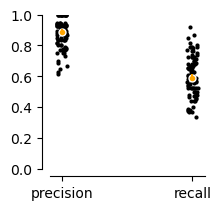

In [11]:
from matplotlib import pyplot as plt
from spikecurate.plotting import plot_precision_recall

stats = result["results"]["metric_stats"]
print(stats)

fig, ax = plt.subplots(1, 1, figsize=(2, 2))
plot_precision_recall(ax, result["results"]["metric_data"])
plt.show()